# CC3 : Calcul scientifique

## 1. Problème aux limites 1D 

### 1.1 Approximation en différence finie

#### 1) Pour c=-1





[[ 20403.  -20402.       0.  ...      0.       0.       0. ]
 [-10251.5  20403.  -10150.5 ...      0.       0.       0. ]
 [     0.  -10251.5  20403.  ...      0.       0.       0. ]
 ...
 [     0.       0.       0.  ...  20403.  -10150.5      0. ]
 [     0.       0.       0.  ... -10251.5  20403.  -10150.5]
 [     0.       0.       0.  ...      0.  -10251.5  20403. ]]


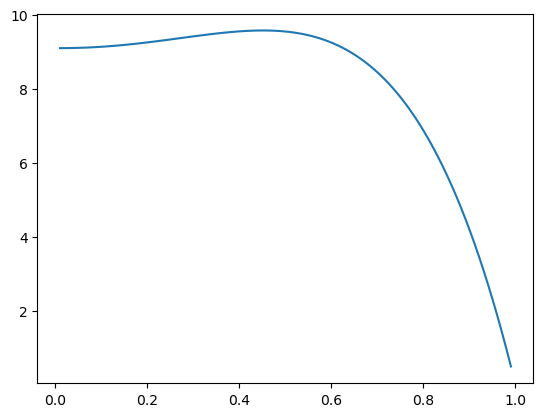

In [68]:
import numpy as np
from scipy.sparse import spdiags
from scipy.sparse.linalg import spsolve
from matplotlib.pylab import *
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags

L = 1
N = 100
h = L/(N+1)
c = -1

x = np.linspace(h, L-h, N)


D0 = (2/h**2 +1) * np.ones(N)
D1 = (-1/h**2 - c/(2*h)) * np.ones(N)
D2 = (-1/h**2 + c/(2*h)) * np.ones(N)

A = spdiags([D2, D0, D1], [-1,0,1], N, N, format='csr')

A[0,0]=2/h**2 +1
A[0,1]=-2/h**2

print(A.toarray())


f=lambda x : 150*x**2
F = f(x)

U = spsolve(A, F)

plot(x,U)




Recherche de u exact

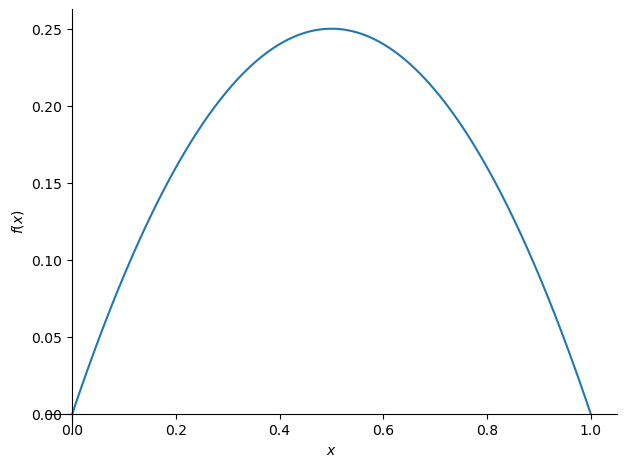

f(x)=


-c*(2*x - 1) - x*(x - 1) + 2

In [69]:
import sympy as sy

x, c = sy.symbols('x c', real=True)

u = x*(L-x)

sy.plot(u,(x,0,1))

print('f(x)=')
ff = - sy.diff(u,x,2) + c*sy.diff(u,x,1) + u
# ff = - sy.diff(u,x,2) -1*sy.diff(u,x,1) + u
ff = ff.simplify() 

display(ff)

f = sy.lambdify(x,ff,'numpy')
u_exact = sy.lambdify(x,u,'numpy')



In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags

L = 1
N = 100
h = L/(N+1)
c = -1

x = np.linspace(h, L-h, N)

D0 = (2/h**2 +1) * np.ones(N)
D1 = (-1/h**2 - c/(2*h)) * np.ones(N)
D2 = (-1/h**2 + c/(2*h)) * np.ones(N)

A = spdiags([D2, D0, D1], [-1,0,1], N, N, format='csr')

A[0,0]=2/h**2 +1
A[0,1]=-2/h**2

def uex(x):
    return u_exact
def f(x):
    return f

u = spsolve(A,f(x))
plt.plot(x,uex(x),label='Exact')
plt.plot(x,u,'--',label='Numerical')
plt.legend()
print("Max error:",np.max(np.abs(u-uex(x))))

IndexError: tuple index out of range

In [ ]:
# calcul de l'ordre de convergence
def erreur(N):
    L = 1
    N = 100
    h = L/(N+1)
    c = -1
    x=np.linspace(h/2,L-h/2,N)
    F=f(x)
    Fchap=dst(F)
    lam=(np.arange(1,N+1)*np.pi/L)**2  
    Uchap=Fchap/lam 
    u= idst(Uchap)/ (2*N)
    return np.max(np.abs(u-uex(x))),x,u,uex(x)
err,x,U,uex_vals=erreur(N)
print("Max error (spectral):",err)
plt.plot(x,uex_vals,label='Exact')
plt.plot(x,U,'--',label='Numerical')
plt.legend()

Ntab=[]
errtab=[]
for N in range(60,6000,80):
    Ntab.append(N)
    err,x,U,uex_vals=erreur(N)
    errtab.append(err)
plt.plot(np.log(Ntab),np.log(errtab),np.log(Ntab),-2*np.log(Ntab))
plt.plot(np.log(Ntab),np.log(errtab),'x')
print("l'ordre de la méthode en h est :",-np.   polyfit(np.log(Ntab),np.log(errtab), 1)[0])

NameError: name 'dst' is not defined

[[ 20403.  -20402.       0.  ...      0.       0.       0. ]
 [-10251.   20403.  -10152.  ...      0.       0.       0. ]
 [     0.  -10250.5  20403.  ...      0.       0.       0. ]
 ...
 [     0.       0.       0.  ...  20403.  -10200.       0. ]
 [     0.       0.       0.  ... -10202.5  20403.  -10200.5]
 [     0.       0.       0.  ...      0.  -10202.   20403. ]]


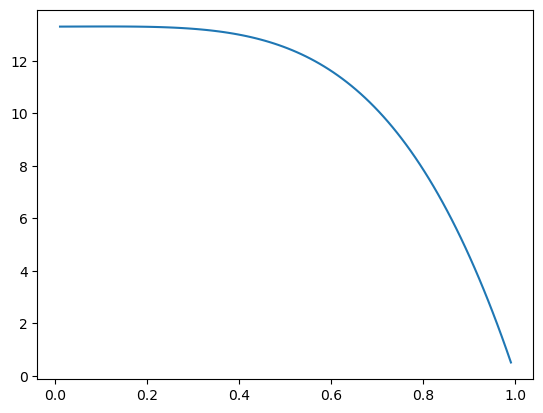

In [ ]:
# c(x) = x-1

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags

L = 1
N = 100
h = L/(N+1)

x = np.linspace(h, L-h, N)

c = x-1

D0 = (2/h**2 +1) * np.ones(N)
D1 = (-1/h**2 - c/(2*h)) * np.ones(N)
D2 = (-1/h**2 + c/(2*h)) * np.ones(N)

A = spdiags([D2, D0, D1], [-1,0,1], N, N, format='csr')

A[0,0]=2/h**2 +1
A[0,1]=-2/h**2

print(A.toarray())


f=lambda x : 150*x**2
F = f(x)

U = spsolve(A, F)

plot(x,U)

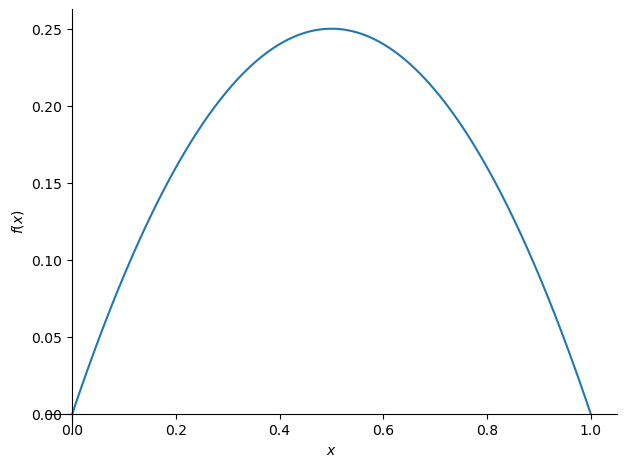

f(x)=


-3*x**2 + 4*x + 1

In [ ]:
import sympy as sy

x= sy.symbols('x', real=True)
c = x-1
u = x*(L-x)

sy.plot(u,(x,0,1))

print('f(x)=')
ff = - sy.diff(u,x,2) + c*sy.diff(u,x,1) + u
# ff = - sy.diff(u,x,2) -1*sy.diff(u,x,1) + u
ff = ff.simplify() 

display(ff)

f = sy.lambdify(x,ff,'numpy')
u_exact = sy.lambdify(x,u,'numpy')



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags

L = 1
N = 100
h = L/(N+1)
c = x-1

x = np.linspace(h, L-h, N)

D0 = (2/h**2 +1) * np.ones(N)
D1 = (-1/h**2 - c/(2*h)) * np.ones(N)
D2 = (-1/h**2 + c/(2*h)) * np.ones(N)

A = spdiags([D2, D0, D1], [-1,0,1], N, N, format='csr')

A[0,0]=2/h**2 +1
A[0,1]=-2/h**2

def uex(x):
    return u_exact
def f(x):
    return f

u = spsolve(A,f(x))
plt.plot(x,uex(x),label='Exact')
plt.plot(x,u,'--',label='Numerical')
plt.legend()
print("Max error:",np.max(np.abs(u-uex(x))))

IndexError: tuple index out of range

In [ ]:
# calcul de l'ordre de convergence
def erreur(N):
    L = 1
    N = 100
    h = L/(N+1)
    x=np.linspace(h/2,L-h/2,N)
    c = x-1
    
    F=f(x)
    Fchap=dst(F)
    lam=(np.arange(1,N+1)*np.pi/L)**2  
    Uchap=Fchap/lam 
    u= idst(Uchap)/ (2*N)
    return np.max(np.abs(u-uex(x))),x,u,uex(x)
err,x,U,uex_vals=erreur(N)
print("Max error (spectral):",err)
plt.plot(x,uex_vals,label='Exact')
plt.plot(x,U,'--',label='Numerical')
plt.legend()

Ntab=[]
errtab=[]
for N in range(60,6000,80):
    Ntab.append(N)
    err,x,U,uex_vals=erreur(N)
    errtab.append(err)
plt.plot(np.log(Ntab),np.log(errtab),np.log(Ntab),-2*np.log(Ntab))
plt.plot(np.log(Ntab),np.log(errtab),'x')
print("l'ordre de la méthode en h est :",-np.   polyfit(np.log(Ntab),np.log(errtab), 1)[0])

NameError: name 'dst' is not defined

## 1.2. Symétrie centrale du problème

## 1.3. Méthode spectrale

f(x)=


-x*(x - 1) + 2

fchap=


array([ 4.33250000e+01, -1.02158645e+00,  2.35922393e-16, -2.61803399e-01,
       -2.60208521e-17, -1.21296000e-01, -3.17454396e-16, -7.23606798e-02,
       -1.66533454e-16, -5.00000000e-02,  1.77635684e-15, -3.81966011e-02,
       -6.10622664e-16, -3.14904046e-02, -7.11236625e-17, -2.76393202e-02,
        2.20309881e-16, -2.56271408e-02, -2.08166817e-16, -2.50000000e-02])

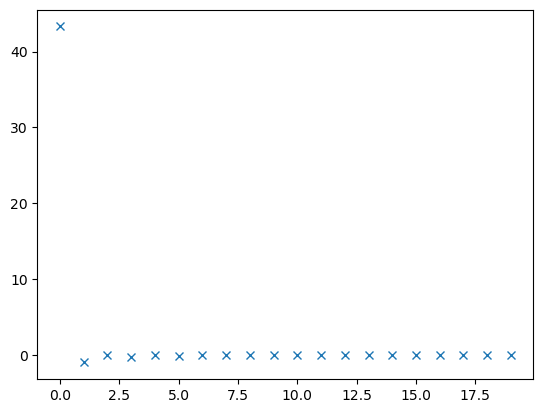

In [73]:
# c= 0
import sympy as sy

x= sy.symbols('x', real=True)
c = 0
u = x*(L-x)

print('f(x)=')
ff = - sy.diff(u,x,2) + c*sy.diff(u,x,1) + u
# ff = - sy.diff(u,x,2) -1*sy.diff(u,x,1) + u
ff = ff.simplify() 

display(ff)

f = sy.lambdify(x,ff,'numpy')
u_exact = sy.lambdify(x,u,'numpy')


from scipy.fftpack import rfft, irfft
N=20
L=1
dx=L/N
x=np.linspace(0,L-dx,N)
fchap=rfft(f(x))
plt.plot(fchap,'x')
print('fchap=')
display(fchap)

Erreur= 2.1639489072601514


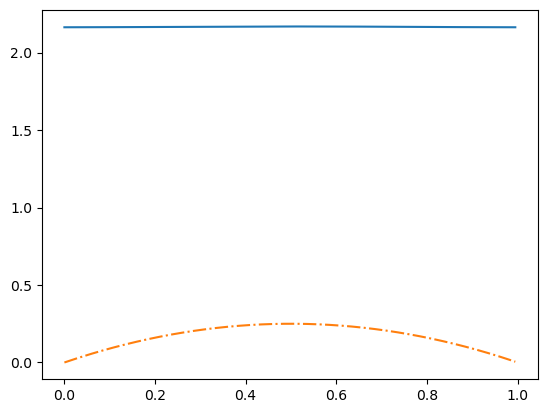

In [78]:
kk=np.arange(0,(N)//2+1)

lammb=(2*np.pi*kk/L)**2
uchap=fchap/(1+lammb)
u=irfft(uchap)

plt.plot(x,u)
plt.plot(x,u_exact(x),'-.')
print('Erreur=',max(abs(u-u_exact(x))))

# 2. Probleme d evolution 1D

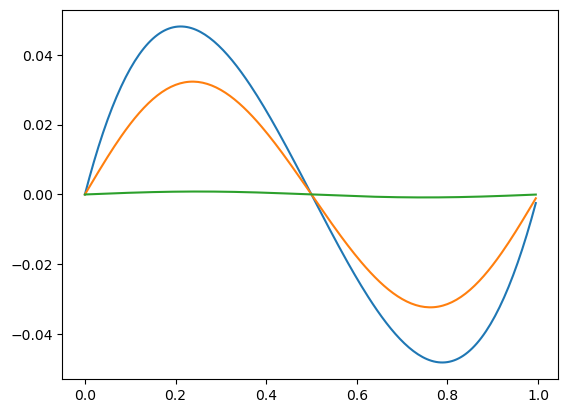

In [79]:
from scipy.fft import rfft, irfft
def u0(x):
    return x*(1-x)*(0.5-x)
L=1
N=200
dx=L/N
x=np.linspace(0,L-dx,N)
u=u0(x)
plt.plot(x,u)
fchap=rfft(u)
kk=np.arange(0,(N)//2+1)
lammb=(2*np.pi*kk/L)**2
t=0.01
uchap=np.exp(-(lammb+1)*t)*fchap
u=irfft(uchap)
plt.plot(x,u)
t=0.1
uchap=np.exp(-(lammb+1)*t)*fchap
u=irfft(uchap)
plt.plot(x,u)